# 01 — EDA

Cette EDA ne sert pas seulement à afficher des graphiques. Chaque bloc répond à une question utile pour la suite : choix de preprocessing, segmentation, gestion des classes rares, adaptation train_audio → soundscapes, et stratégie multi-label.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))
print('PROJECT_ROOT =', PROJECT_ROOT)


PROJECT_ROOT = c:\Users\yeyuy\Downloads\projet_ml_audio_classique_v7_structured\projet_ml_audio_classique_v7_structured


## 1. Vérifier les fichiers disponibles

In [2]:
from src.config import DATA_DIR, TRAIN_AUDIO_DIR, TRAIN_SOUNDSCAPES_DIR, TEST_SOUNDSCAPES_DIR, TRAIN_CSV, SOUNDSCAPE_LABELS_CSV, TAXONOMY_CSV
for p in [DATA_DIR, TRAIN_AUDIO_DIR, TRAIN_SOUNDSCAPES_DIR, TEST_SOUNDSCAPES_DIR, TRAIN_CSV, SOUNDSCAPE_LABELS_CSV, TAXONOMY_CSV]:
    print(f'{p.relative_to(PROJECT_ROOT)} ->', 'OK' if p.exists() else 'MANQUANT')

data -> OK
data\train_audio -> OK
data\train_soundscapes -> OK
data\test_soundscapes -> OK
data\train.csv -> OK
data\train_soundscapes_labels.csv -> OK
data\taxonomy.csv -> OK


## 2. Scanner `train_audio` et résumer les classes

Question : le problème est-il fortement déséquilibré ?

(35549, 18)


,filepath,filename,stem,label,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,collection
0,C:\Users\yeyuy\Downloads\projet_ml_audio_class...,iNat1114648.ogg,iNat1114648,1161364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,C:\Users\yeyuy\Downloads\projet_ml_audio_class...,iNat1216197.ogg,iNat1216197,1161364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,C:\Users\yeyuy\Downloads\projet_ml_audio_class...,iNat1264238.ogg,iNat1264238,1161364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C:\Users\yeyuy\Downloads\projet_ml_audio_class...,iNat547199.ogg,iNat547199,1161364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,C:\Users\yeyuy\Downloads\projet_ml_audio_class...,iNat556514.ogg,iNat556514,1161364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


count    206.000000
mean     172.567961
std      155.371004
min        1.000000
25%       47.250000
50%      125.000000
75%      243.750000
max      499.000000
Name: count, dtype: float64

Classes avec <=2 exemples: 7
Classes avec <=5 exemples: 18


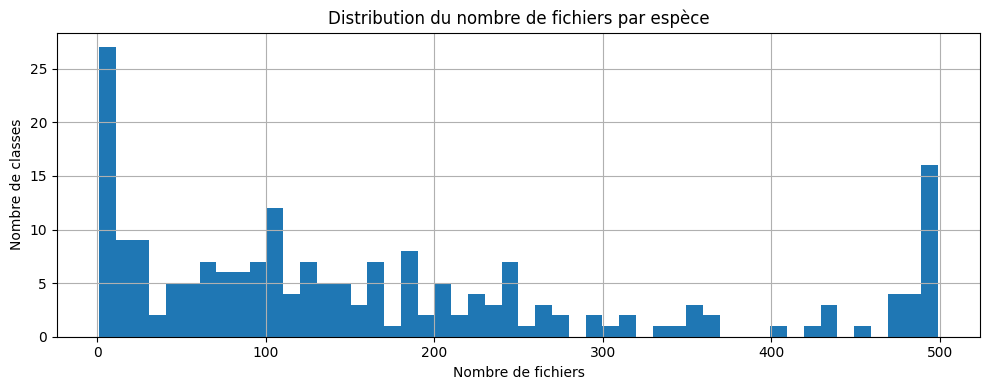

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.data_loading import scan_train_audio, scan_soundscapes
from src.config import FIGURE_DIR, OUTPUT_DIR

df_train = scan_train_audio()
print(df_train.shape)
display(df_train.head())
counts = df_train['label'].value_counts()
display(counts.describe())
print('Classes avec <=2 exemples:', int((counts <= 2).sum()))
print('Classes avec <=5 exemples:', int((counts <= 5).sum()))
counts.to_csv(OUTPUT_DIR / 'train_audio_class_counts.csv')
plt.figure(figsize=(10,4))
counts.hist(bins=50)
plt.title('Distribution du nombre de fichiers par espèce')
plt.xlabel('Nombre de fichiers')
plt.ylabel('Nombre de classes')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_class_distribution.png')
plt.show()

Le jeu de données présente un déséquilibre marqué. le nomrbre de fichiers par espèce varie de 1 à 4999 enregistrements avec une médiane de 125 et un écart-type élevé. -> une forte dispersion des effectifs

certaines classes sont particulièrement sous-représentées, 7 espèces possèdes <=2 exemples et 18 espèces <= 5 exemplaires. En parallèle,plusieurs classes possède plusieurs centaines d'enregistrements.

--> Cette distribution non uniforme peut biaiser l’apprentissage en faveur des classes majoritaires. Pour limiter cet effet, on va activer la pondération des classes ``class_weight="balanced"``.

## 3. Durées des audios

Question : faut-il tronquer, segmenter, ou garder l'audio complet ?

count    35549.000000
mean        34.882595
std         74.861287
min          0.008000
10%          5.851438
25%         10.788562
50%         21.000000
75%         39.837313
90%         70.920488
95%        103.580600
99%        223.157280
max       6881.097000
Name: duration_sec, dtype: float64

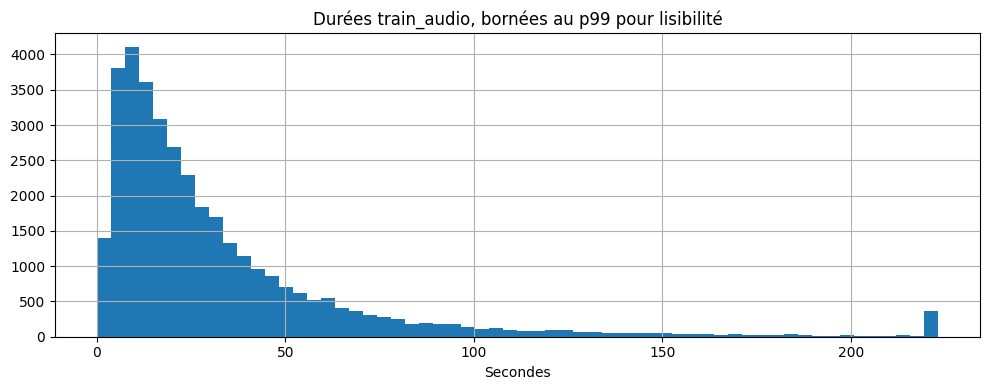

In [4]:
from joblib import Parallel, delayed
from src.eda_utils import safe_duration
from src.config import N_JOBS, FIGURE_DIR

df_train['duration_sec'] = Parallel(n_jobs=N_JOBS)(delayed(safe_duration)(p) for p in df_train['filepath'])
display(df_train['duration_sec'].describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]))
plt.figure(figsize=(10,4))
df_train['duration_sec'].dropna().clip(upper=df_train['duration_sec'].quantile(.99)).hist(bins=60)
plt.title('Durées train_audio, bornées au p99 pour lisibilité')
plt.xlabel('Secondes')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_duration_train_audio.png')
plt.show()

durées des enregistrements présentent une forte variabilité avec une médiane de 21s mais des fichiers pouvant dépasser 200s. l'histogramme démontre une forte asymétrique de distribution.

pour éviter des entrées de taille hétérogènes et un coût de calcul trop élevé, on applique la segmentation des signaux en fenêtres de durée fixe avec recouvrement partiel pour homogénéiser les données et préserver davantage d'information temporelle, cette application permet aussi d'augumenter le nombre d'exemples pour l'apprentissage.

## 4. Qualité signal : énergie, silence, fréquence

Question : les fichiers contiennent-ils beaucoup de silence ou de bruit basse fréquence ?

-> normalisation, preemphasis, filtre bandpass, features robustes `mean/std/percentiles`.

c:\Users\yeyuy\Downloads\projet_ml_audio_classique_v7_structured\projet_ml_audio_classique_v7_structured\src\eda_utils.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(label_col, group_keys=False).apply(lambda x: x.sample(min(len(x), n), random_state=random_state))
c:\Users\yeyuy\Downloads\projet_ml_audio_classique_v7_structured\projet_ml_audio_classique_v7_structured\src\eda_utils.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns a

,duration,rms_mean,zcr_mean,centroid_mean,bandwidth_mean,flatness_mean
count,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000
mean,19.865165,0.061841,0.371509,6390.602934,2986.593678,0.023006
std,9.879821,0.047984,0.103709,1341.327079,602.980343,0.021276
min,0.048000,0.001799,0.104040,2585.974318,1326.540870,0.000180
25%,9.985305,0.026299,0.304029,5542.554900,2599.231071,0.004844
50%,22.143859,0.046795,0.359332,6389.507108,3027.897895,0.015356
75%,30.000000,0.080106,0.427439,7236.310660,3443.320746,0.037731
max,30.000000,0.236391,0.659559,9732.942509,4592.798799,0.094143


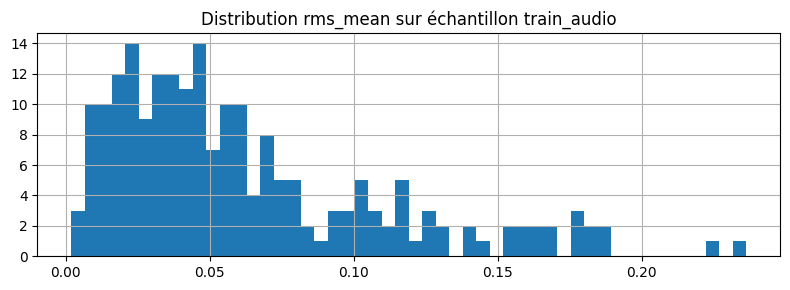

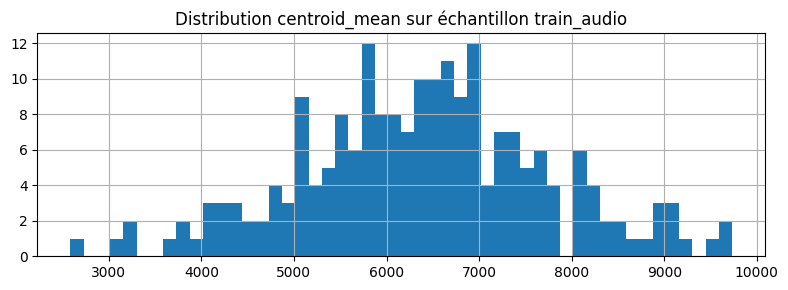

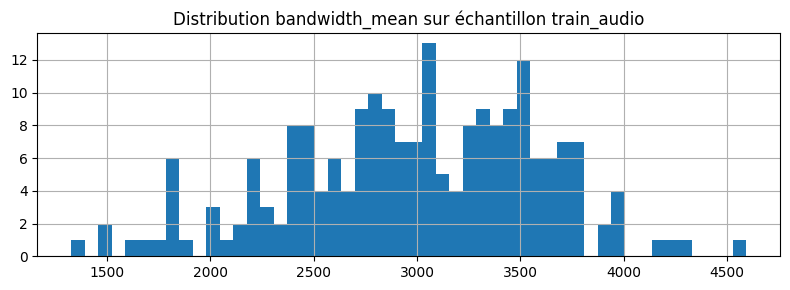

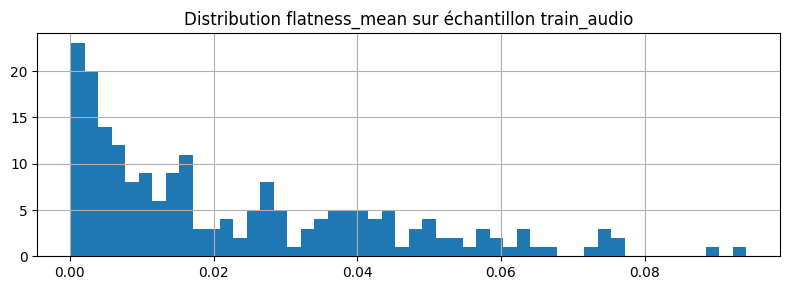

In [5]:
from src.eda_utils import quick_audio_stats, sample_per_class
sample_df = sample_per_class(df_train, n=1).sample(min(300, len(sample_per_class(df_train, n=1))), random_state=42)
stats = Parallel(n_jobs=N_JOBS)(delayed(quick_audio_stats)(p) for p in sample_df['filepath'])
df_stats = pd.concat([sample_df.reset_index(drop=True), pd.DataFrame(stats)], axis=1)
display(df_stats[['label','duration','rms_mean','zcr_mean','centroid_mean','bandwidth_mean','flatness_mean']].describe())
df_stats.to_csv(OUTPUT_DIR / 'eda_audio_quality_sample.csv', index=False)
for col in ['rms_mean','centroid_mean','bandwidth_mean','flatness_mean']:
    plt.figure(figsize=(8,3))
    df_stats[col].dropna().hist(bins=50)
    plt.title(f'Distribution {col} sur échantillon train_audio')
    plt.tight_layout(); plt.savefig(FIGURE_DIR / f'eda_{col}.png'); plt.show()

les sorties indique une qualité de signal hétérogène.Les faibles valeurs d’énergie (rms_mean) observées sur une partie des fichiers suggèrent la présence de segments silencieux ou faiblement informatifs. De plus, certaines distributions présentent une concentration vers les basses fréquences, ce qui peut correspondre à du bruit de fond environnemental.

Les valeurs de centroid et de bandwidth restent néanmoins relativement élevées pour une grande partie des enregistrements, indiquant que de nombreuses vocalisations utiles occupent des bandes de fréquence variées. La faible spectral flatness observée sur la majorité des fichiers montre également la présence de structures harmoniques plutôt que d’un bruit blanc dominant.

solution: normalisation du signal, filtre band-pass pour atténuer les basses fréquences parasites, préaccentuation pre-emphasis et extraction de statistiques robustes mean, std, percentiles sur les descripteurs acoustiques.

## 5. Comparer train_audio et train_soundscapes

Question centrale : y a-t-il un domain shift ?

-> si les soundscapes ont plus de bruit et de longues durées, on ne peut pas appliquer naïvement un modèle mono-label ; il faut segmentation + seuil multi-label + fusion top modèles.

Soundscapes: (10658, 4)


,filepath,filename,stem,label
0,C:\Users\yeyuy\Downloads\projet_ml_audio_class...,BC2026_Train_0001_S08_20250606_030007.ogg,BC2026_Train_0001_S08_20250606_030007,None
1,C:\Users\yeyuy\Downloads\projet_ml_audio_class...,BC2026_Train_0002_S08_20250607_030007.ogg,BC2026_Train_0002_S08_20250607_030007,None
2,C:\Users\yeyuy\Downloads\projet_ml_audio_class...,BC2026_Train_0003_S08_20250607_070007.ogg,BC2026_Train_0003_S08_20250607_070007,None
3,C:\Users\yeyuy\Downloads\projet_ml_audio_class...,BC2026_Train_0004_S08_20250607_070007.ogg,BC2026_Train_0004_S08_20250607_070007,None
4,C:\Users\yeyuy\Downloads\projet_ml_audio_class...,BC2026_Train_0005_S08_20250607_070007.ogg,BC2026_Train_0005_S08_20250607_070007,None


rms_mean                     centroid_mean               \
                 mean    median       std          mean       median   
source                                                                 
soundscape   0.136745  0.137047  0.059835   6679.382425  6726.283581   
train_audio  0.061841  0.046795  0.047984   6390.602934  6389.507108   

                         bandwidth_mean                           \
                     std           mean       median         std   
source                                                             
soundscape    823.320327    2461.865167  2418.335840  475.053443   
train_audio  1341.327079    2986.593678  3027.897895  602.980343   

            flatness_mean                      
                     mean    median       std  
source                                         
soundscape       0.006413  0.003089  0.010550  
train_audio      0.023006  0.015356  0.021276

<Figure size 600x400 with 0 Axes>

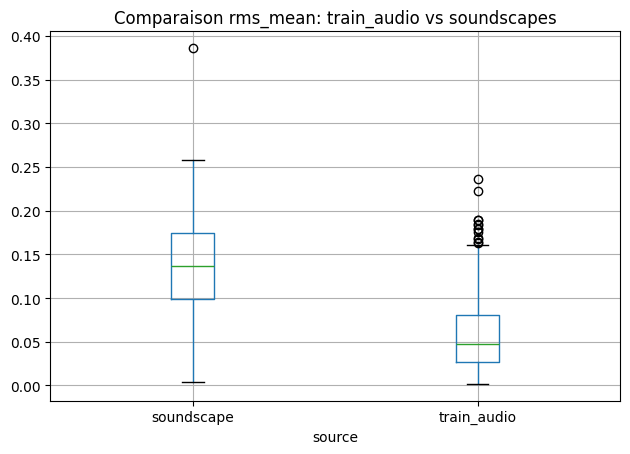

<Figure size 600x400 with 0 Axes>

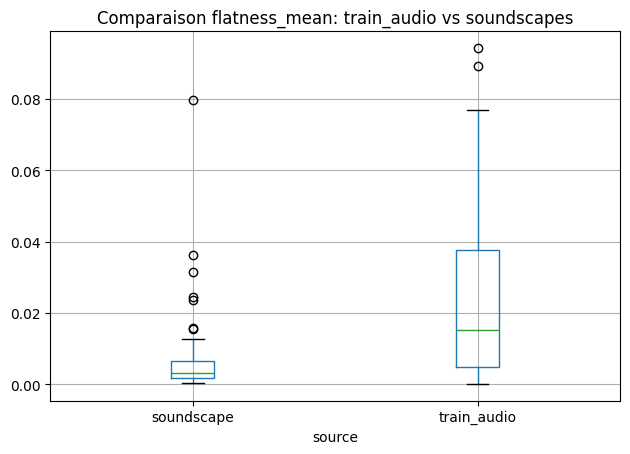

<Figure size 600x400 with 0 Axes>

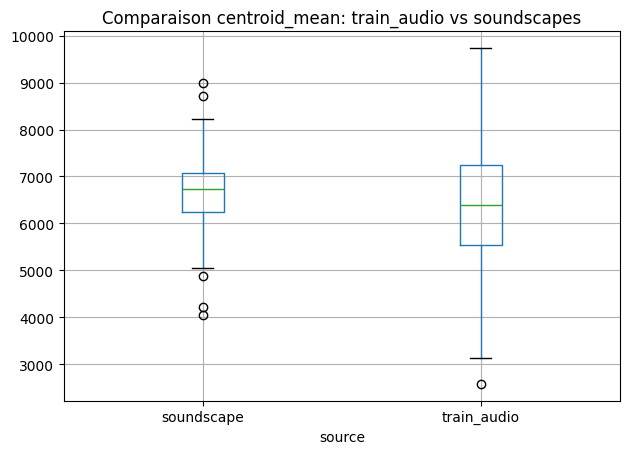

In [6]:
df_sound = scan_soundscapes(train=True)
print('Soundscapes:', df_sound.shape)
display(df_sound.head())
if not df_sound.empty:
    sound_sample = df_sound.sample(min(80, len(df_sound)), random_state=42)
    sound_stats = Parallel(n_jobs=N_JOBS)(delayed(quick_audio_stats)(p, max_seconds=30) for p in sound_sample['filepath'])
    df_sound_stats = pd.concat([sound_sample.reset_index(drop=True), pd.DataFrame(sound_stats)], axis=1)
    df_stats['source'] = 'train_audio'
    df_sound_stats['source'] = 'soundscape'
    comp = pd.concat([df_stats[['source','rms_mean','centroid_mean','bandwidth_mean','flatness_mean']], df_sound_stats[['source','rms_mean','centroid_mean','bandwidth_mean','flatness_mean']]], ignore_index=True)
    display(comp.groupby('source').agg(['mean','median','std']))
    for col in ['rms_mean','flatness_mean','centroid_mean']:
        plt.figure(figsize=(6,4))
        comp.boxplot(column=col, by='source')
        plt.title(f'Comparaison {col}: train_audio vs soundscapes')
        plt.suptitle('')
        plt.tight_layout(); plt.savefig(FIGURE_DIR / f'eda_domain_shift_{col}.png'); plt.show()

Les distributions montrent un décalage notable entre train_audio et soundscapes (un domain shift). Les soundscapes présentent une énergie moyenne (rms_mean) nettement plus élevée, ce qui suggère un bruit de fond plus important et des environnements acoustiques plus denses. À l’inverse, les fichiers de train_audio possèdent une spectral flatness plus élevée et une dispersion fréquentielle plus large (bandwidth_mean), traduisant des enregistrements plus variés mais plus propres et centrés sur une espèce dominante. ce résultat est coherent avec le jeu de données et ces différences impliquent qu’un apprentissage mono-label direct sur train_audio généraliserait difficilement aux soundscapes.

## 6. Labels soundscapes : multi-label réel

Question : combien d'espèces peuvent être présentes sur une ligne soundscape ?

label_col = primary_label


count    1478.000000
mean        4.224628
std         1.783362
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max        10.000000
Name: n_labels, dtype: float64

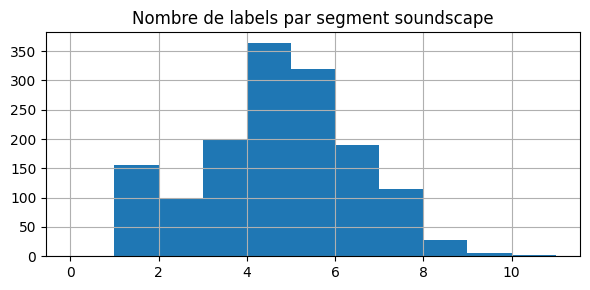

In [7]:
from src.config import SOUNDSCAPE_LABELS_CSV
from src.data_loading import parse_multilabel
if SOUNDSCAPE_LABELS_CSV.exists():
    lab = pd.read_csv(SOUNDSCAPE_LABELS_CSV)
    label_col = next((c for c in ['birds','labels','primary_label'] if c in lab.columns), None)
    print('label_col =', label_col)
    if label_col:
        lab['n_labels'] = lab[label_col].apply(lambda x: len(parse_multilabel(x)))
        display(lab['n_labels'].describe())
        plt.figure(figsize=(6,3))
        lab['n_labels'].hist(bins=range(0, max(2, lab['n_labels'].max()+2)))
        plt.title('Nombre de labels par segment soundscape')
        plt.tight_layout(); plt.savefig(FIGURE_DIR / 'eda_soundscape_multilabel_count.png'); plt.show()

Chaque segment de soundscape contient en moyenne 4 à 5 labels simultanés, avec certains segments atteignant jusqu’à 10 espèces présentes, la cooccurrence d’espèces constitue donc une caractéristique centrale des données de test.

## 7. Conclusion EDA → décisions du pipeline

EDA met en évidence plusieurs contraintes structurantes du problème. Le jeu de données est fortement déséquilibré, avec certaines espèces très peu représentées. 

une pondération des classes sera donc utilisée à la suite et les classes trop rares pourront être exclues temporairement lors de certaines validations croisées. Les différences observées entre train_audio et soundscapes révèlent également un domain shift important, nécessitant un prétraitement adapté et une légère augmentation des données.

les soundscapes étant naturellement multi-label, le pipeline reposera sur des prédictions par segment suivies d’une fusion des scores avec sélection top-k et ajustement des seuils.